# PCA of sea level pressure fields (ERA5, North Pacific)

Summarize daily ERA5 pressure over the selected **North Pacific rectangle** with two PCA models: pressure alone, and pressure plus its spatial-gradient predictor.

The geographic crop is applied at the start, **before loading full-resolution fields and before averaging onto the 2° grid**:

- Latitude: **31.823246°N to 56.885930°N**.
- Longitude: **147.954232°W to 122.997241°W** (212.045768°E to 237.002759°E).

Use 1979–2025, inspect the regional fields, fit the two PCA models, explore EOFs and PCs, and save regional models for `waves_regression.ipynb`.


In [1]:
import logging
import os
import warnings
warnings.filterwarnings("ignore")

# Hide bluemath_tk PCA log messages below ERROR
logging.getLogger("PCA").setLevel(logging.ERROR)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from bluemath_tk.core.operations import spatial_gradient
from bluemath_tk.datamining.pca import PCA

## 1. Load and crop ERA5 sea level pressure

The source covers a larger Pacific domain, but only the requested North Pacific rectangle is selected below. Opening the file reads metadata; selecting coordinates restricts the data before any yearly `.load()` operation. Longitude bounds are converted to the file's 0–360° convention. Boolean coordinate selection works with either latitude order.


In [2]:
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "toolkit" / "data" / "outputs").is_dir())
data_path = str(repo_root / "toolkit" / "data" / "outputs")
msl_file = os.path.join(
    data_path, "era5_pacific_1940-01-01_to_2026-12-31_lat-60to60_lon100to290_msl.nc"
)
south, north = 31.823246, 56.885930
west, east = -147.954232, -122.997241
region_id = "north_pacific_31.823246N-56.885930N_147.954232W-122.997241W"
map_center = ((west + east) / 2, (south + north) / 2)

raw = xr.open_dataset(msl_file).rename(valid_time="time")
raw = raw.isel(
    latitude=(raw.latitude >= south) & (raw.latitude <= north),
    longitude=(raw.longitude >= west % 360) & (raw.longitude <= east % 360),
)
if raw.sizes["latitude"] == 0 or raw.sizes["longitude"] == 0:
    raise ValueError("The requested North Pacific region does not intersect the data.")
print(f"North Pacific crop: {dict(raw.sizes)}")
raw


North Pacific crop: {'time': 31655, 'latitude': 100, 'longitude': 100}


### Average the cropped region onto a coarser grid

Select 1979–2025 and average each **8 × 8 spatial block** (0.25° → 2°), reading one year at a time. The crop contains **100 × 100** source points. With `boundary="trim"`, the incomplete edge blocks are removed, leaving **12 × 12 = 144** regional predictors per variable.

A dedicated cache includes the region bounds in its filename, so the earlier full-Pacific cache cannot be reused accidentally. Pressure stays in Pa on disk and is converted to hPa in memory.


In [3]:
years = range(1979, 2026)
coarsen_factor = 8  # Average 8 x 8 cells: 0.25° -> 2°
resolution = 0.25 * coarsen_factor

reduced_file = os.path.join(
    data_path,
    f"era5_{region_id}_msl_{years[0]}-{years[-1]}_{resolution:g}deg_blockmean_Pa.nc",
)

if not os.path.exists(reduced_file):
    yearly = []
    for year in years:
        msl_year = raw.msl.sel(time=str(year)).load()
        yearly.append(
            msl_year.coarsen(
                latitude=coarsen_factor,
                longitude=coarsen_factor,
                boundary="trim",
            ).mean(keep_attrs=True)
        )
    reduced = xr.concat(yearly, dim="time")
    reduced.attrs.update(units="Pa", region_id=region_id, south=south, north=north, west=west, east=east)
    # Use the repository's local-scratch writer for iCloud-backed paths.
    import sys
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    from toolkit.data.utils.ndbc_data import save_netcdf
    save_netcdf(reduced.to_dataset(name="msl"), reduced_file)
    del yearly, msl_year, reduced


In [4]:
# Load the small cache, close the file, and convert Pa -> hPa in memory.
with xr.open_dataset(reduced_file) as reduced:
    msl = (reduced.msl.load() / 100).transpose("time", "latitude", "longitude")
msl.attrs.update(long_name="North Pacific mean sea level pressure", units="hPa")
assert bool(((msl.latitude >= south) & (msl.latitude <= north)).all())
assert bool(((msl.longitude >= west % 360) & (msl.longitude <= east % 360)).all())
print(f"PCA input: {msl.sizes['latitude']} × {msl.sizes['longitude']} regional cells")
msl

PCA input: 12 × 12 regional cells


## 2. Explore the regional data

Compare the original and block-averaged pressure for the **same North Pacific rectangle**. Every subsequent PCA uses this cropped domain.


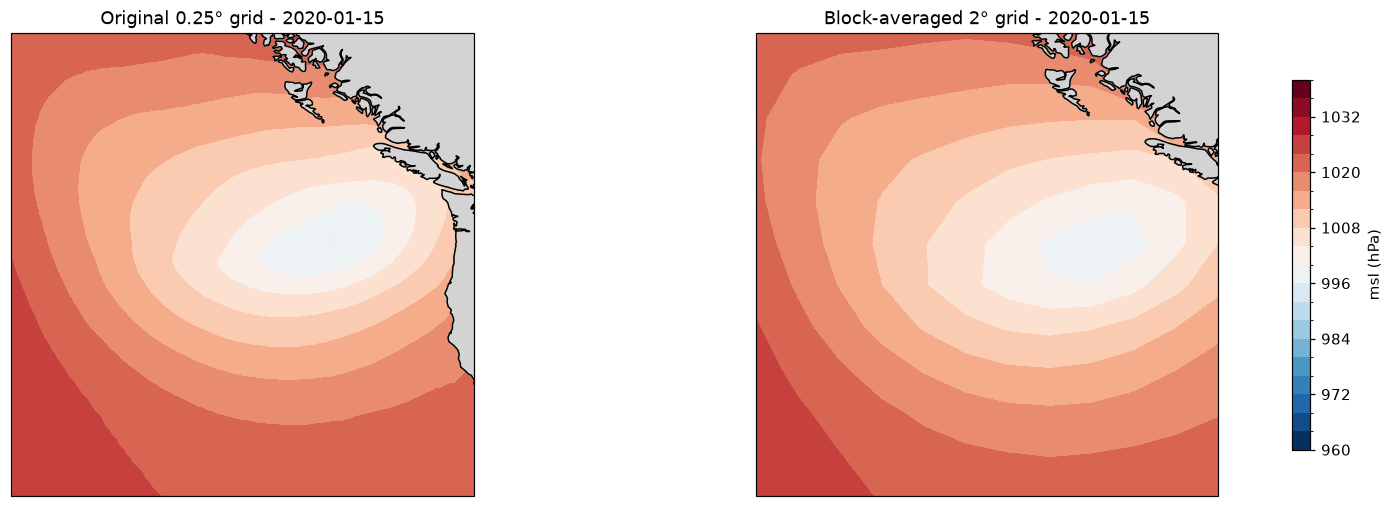

In [5]:
date = "2020-01-15"
proj = ccrs.PlateCarree(central_longitude=map_center[0])
levels = np.arange(960, 1041, 4)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), subplot_kw={"projection": proj}, layout="constrained")
for ax, field, title in zip(
    axes,
    [raw.msl.sel(time=date) / 100, msl.sel(time=date)],
    ["Original 0.25° grid", f"Block-averaged {resolution:g}° grid"],
):
    cf = field.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r", add_colorbar=False)
    ax.add_feature(cfeature.LAND, color="lightgrey", zorder=2)
    ax.coastlines(zorder=3)
    ax.set_title(f"{title} - {date}")
fig.colorbar(cf, ax=axes, shrink=0.8, label="msl (hPa)");

As in `PCA_theory.ipynb`, the data are a **3D block** (`time` × `latitude` × `longitude`), and PCA needs a 2D matrix. Each daily map is flattened into one row, so `time` gives the observations and every grid point is a feature:

In [6]:
n_times, n_lat, n_lon = msl.shape
print(f"{n_times} days x ({n_lat} lat x {n_lon} lon) -> PCA matrix of {n_times} rows x {n_lat * n_lon} columns")

17167 days x (12 lat x 12 lon) -> PCA matrix of 17167 rows x 144 columns


## 3. Fit the PCA

The call is the same as in the theory notebook:

- `vars_to_stack=["msl"]`: the variable used as predictor.
- `coords_to_stack=["latitude", "longitude"]`: every grid point becomes a feature (column).
- `pca_dim_for_rows="time"`: every day becomes an observation (row).
- `n_components=0.95`: keep as many components as needed to explain **95% of the variance**.

The data are standardized by default (`scale_data=True`), so every grid point contributes with unit variance.

In [7]:
era5 = msl.to_dataset()

pca = PCA(n_components=0.95)
pcs = pca.fit_transform(
    data=era5,
    vars_to_stack=["msl"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

print(f"{pca.pca.n_components_} components explain {pca.cumulative_explained_variance_ratio[-1]:.1%} of the variance")
pcs

5 components explain 95.8% of the variance


### How many components?

The 144 regional grid points are compressed into a smaller set of components that retain 95% of the variance. The plots below show how much each component contributes and how many are needed to reach different cumulative thresholds.


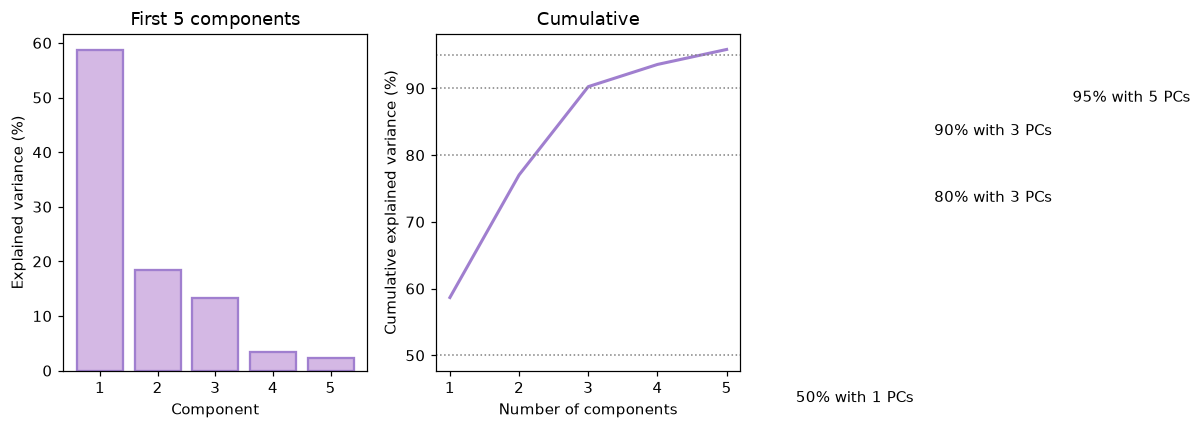

In [8]:
n = np.arange(1, pca.pca.n_components_ + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), tight_layout=True)
axes[0].bar(n[:20], pca.explained_variance_ratio[:20] * 100, color="#d4b8e4", edgecolor="#a07fcf", linewidth=1.5)
axes[0].set(xlabel="Component", ylabel="Explained variance (%)", title=f"First {min(20, len(n))} components")
axes[1].plot(n, pca.cumulative_explained_variance_ratio * 100, color="#a07fcf", linewidth=2)
for threshold in [50, 80, 90, 95]:
    k = np.argmax(pca.cumulative_explained_variance_ratio * 100 >= threshold) + 1
    axes[1].axhline(threshold, color="grey", linestyle=":", linewidth=1)
    axes[1].annotate(f"{threshold}% with {k} PCs", (k, threshold), xytext=(k + 5, threshold - 7))
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance (%)", title="Cumulative")

## 4. Reconstruct a daily field

Each day is now described only by its PC values. `inverse_transform` goes back from those values to a full pressure map. Comparing it with the original shows how much is lost with the retained components.

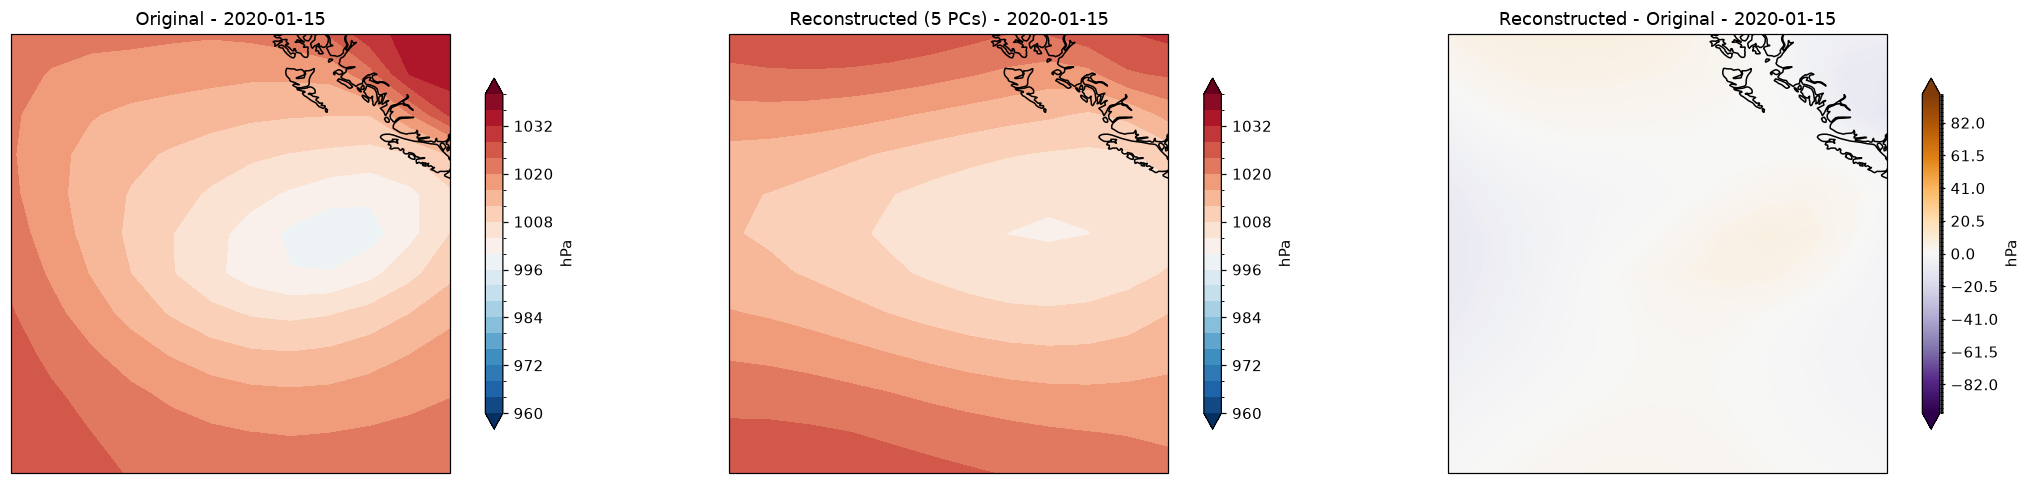

In [9]:
reconstructed = pca.inverse_transform(PCs=pcs.sel(time=[date])).msl.squeeze()
original = msl.sel(time=date)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5), subplot_kw={"projection": proj}, tight_layout=True)
panels = [
    (original, "Original", levels, "RdBu_r"),
    (reconstructed, f"Reconstructed ({pca.pca.n_components_} PCs)", levels, "RdBu_r"),
    (reconstructed - original, "Reconstructed - Original", np.arange(-100, 100.5, 0.5), "PuOr_r"),
]
for ax, (field, title, lev, cmap) in zip(axes, panels):
    field.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(), levels=lev, cmap=cmap, extend="both",
        cbar_kwargs={"label": "hPa", "shrink": 0.8},
    )
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

## 5. Spatial modes (EOFs)

These EOFs describe covariance within the selected North Pacific rectangle. They are newly fitted regional patterns, not crops of the full-Pacific EOFs. Their signs are arbitrary. Inspect the maps together with their PCs before assigning a circulation interpretation; physical interpretations from the earlier full-Pacific analysis do not automatically apply here.


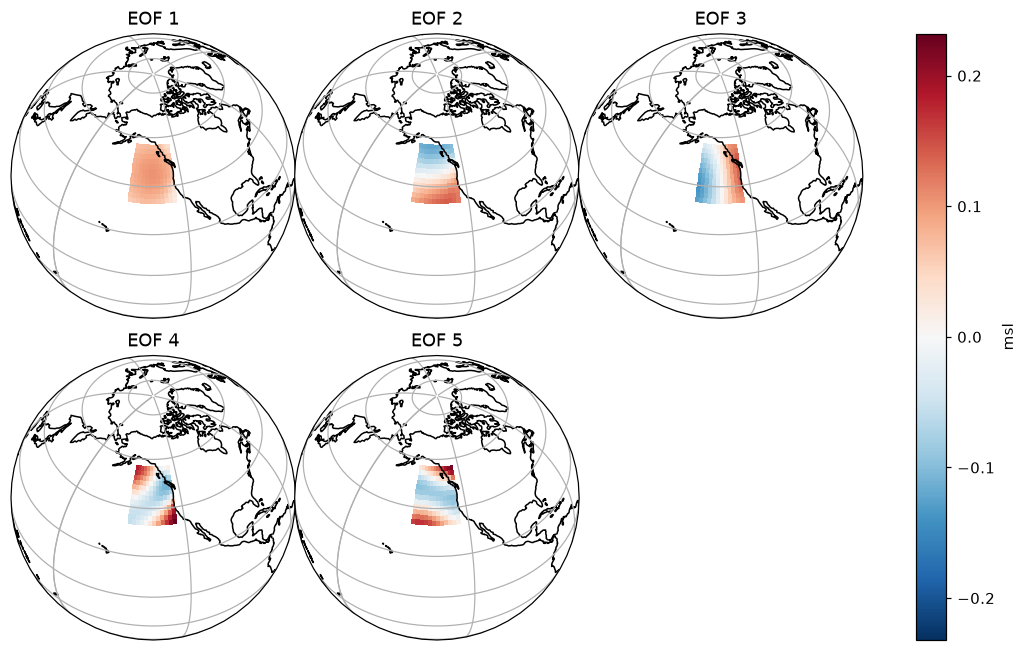

In [10]:
pca.plot_eofs(vars_to_plot=["msl"], num_eofs=min(6, pca.pca.n_components_), map_center=map_center)

## 6. Temporal indices (PCs)

Show the first three regional PCs over the full record and a zoom for 2015–2018. Each score describes the daily amplitude of its regional EOF. The explained-variance ratios refer to the cropped pressure field.


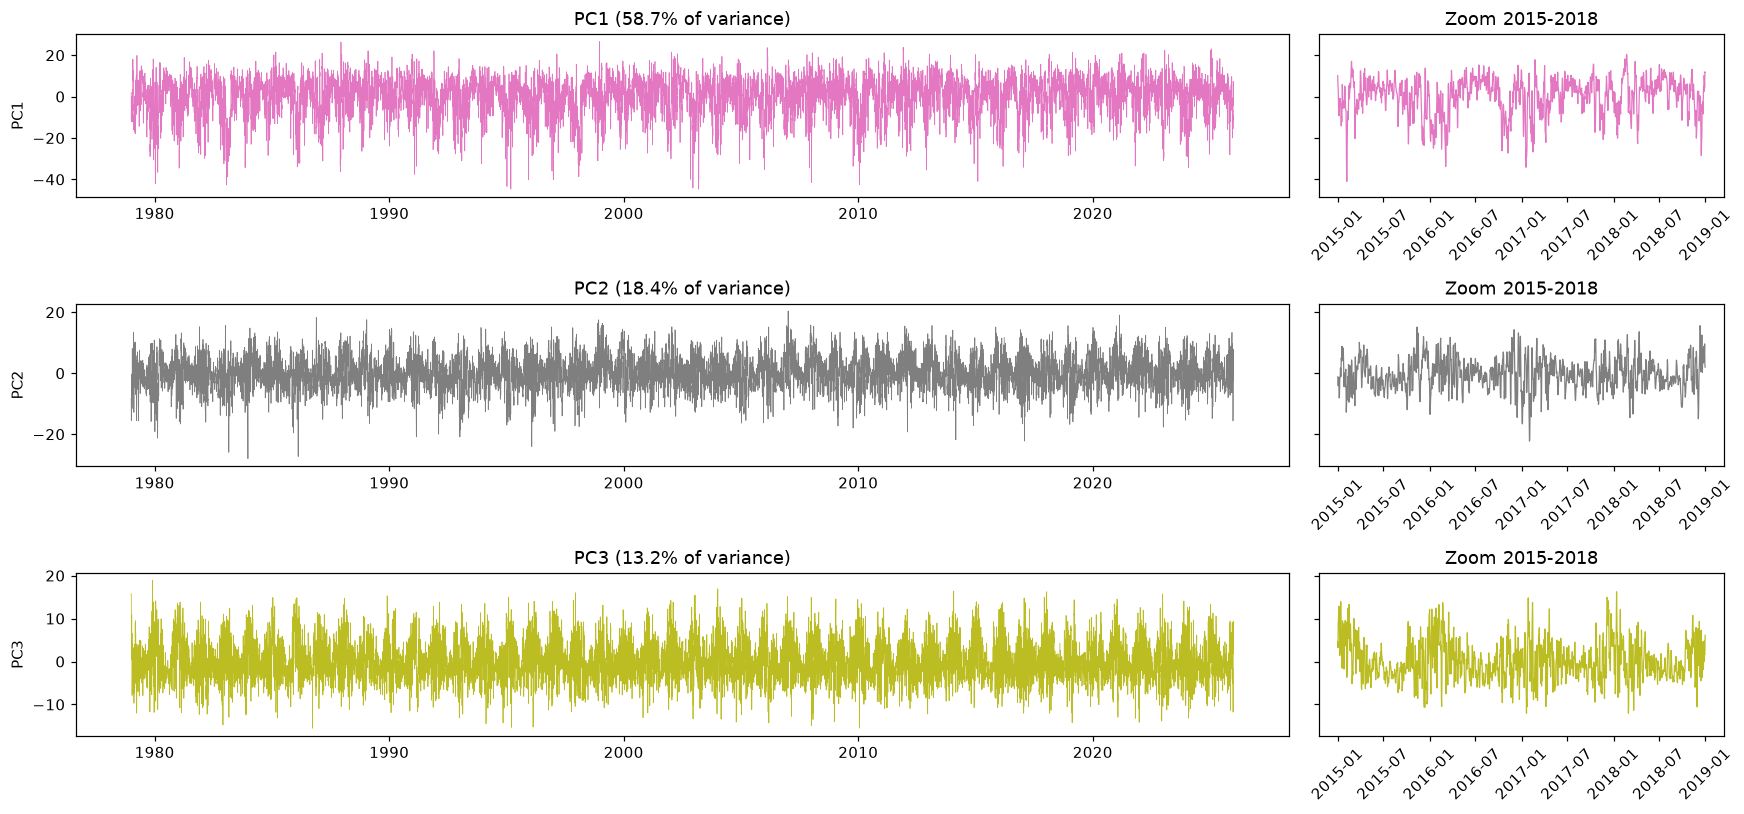

In [11]:
n_pcs = min(3, pcs.sizes["n_component"])

fig, axes = plt.subplots(n_pcs, 2, figsize=(16, 2.5 * n_pcs), sharey="row", tight_layout=True,
                         gridspec_kw={"width_ratios": [3, 1]})
for i in range(n_pcs):
    pc = pcs.PCs.isel(n_component=i)
    ratio = pca.explained_variance_ratio[i]

    axes[i, 0].plot(pc.time, pc, color = f"C{i + 6}", linewidth=0.5)
    # axes[i, 0].plot(pc.time, pc.rolling(time=365, center=True).mean(), color=f"C{i}", linewidth=1.5)
    axes[i, 0].set(ylabel=f"PC{i + 1}", title=f"PC{i + 1} ({ratio:.1%} of variance)")

    zoom = pc.sel(time=slice("2015", "2018"))
    axes[i, 1].plot(zoom.time, zoom, color=f"C{i + 6}", linewidth=0.8)
    axes[i, 1].set(title="Zoom 2015-2018")
    axes[i, 1].tick_params(axis="x", labelrotation=45)

## 7. Adding the msl gradient

Pressure gradients drive wind, so we add a predictor of spatial pressure variation alongside msl. We compute it **after coarsening**, from the same 2° pressure fields used above, with [`bluemath_tk.core.operations.spatial_gradient`](https://geoocean.github.io/BlueMath_tk/_modules/bluemath_tk/core/operations.html#spatial_gradient). The input is a `DataArray` ordered as (`time`, `latitude`, `longitude`).

The published implementation sums squared neighboring pressure differences, with a cosine correction for longitude differences, and leaves the outermost grid cells at zero. It does not take a square root or divide by grid spacing in physical distance. Here `msl_gradient` therefore represents a **squared pressure-difference predictor**, in **hPa²** for our hPa input, rather than a gradient magnitude in hPa/km. We correct its metadata because the function assigns a fixed unit label unrelated to the input pressure units. The zero-valued boundary is an implementation convention, not an observed absence of pressure variation.


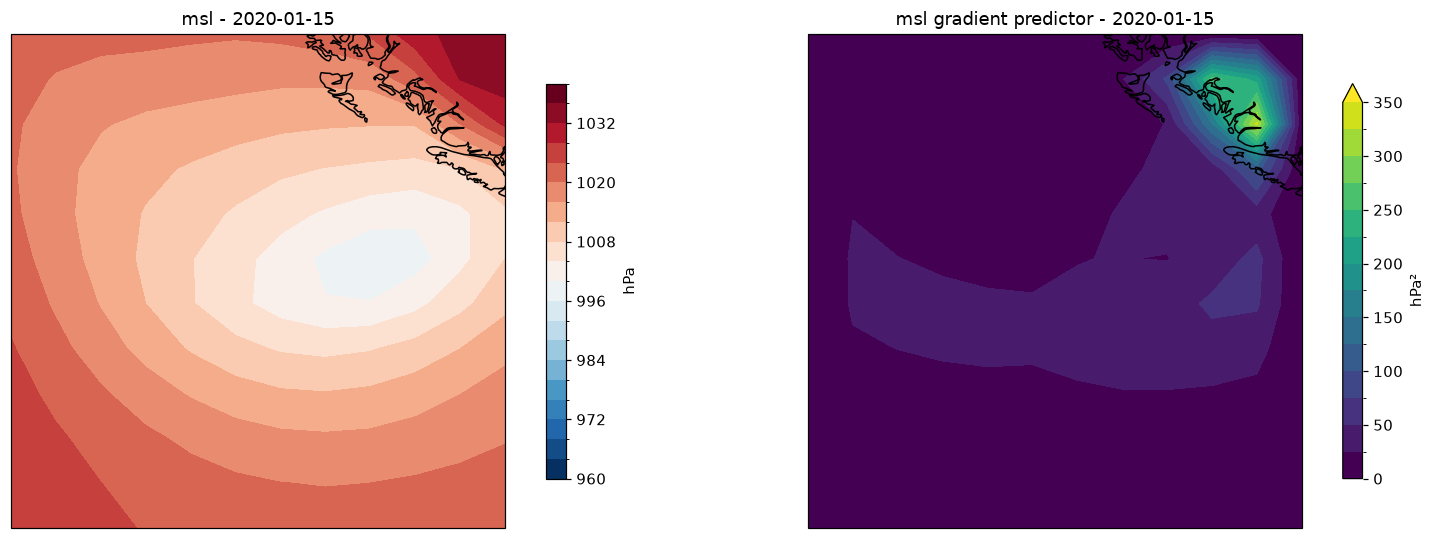

In [12]:
era5["msl_gradient"] = spatial_gradient(msl)
era5["msl_gradient"].attrs = {
    "long_name": "Squared spatial pressure-difference predictor",
    "units": "hPa^2",
    "description": "BlueMath spatial_gradient on the coarsened hPa field; zero outer boundary",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={"projection": proj}, tight_layout=True)
era5.msl.sel(time=date).plot.contourf(ax=axes[0], transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r",
                                      cbar_kwargs={"label": "hPa", "shrink": 0.8})
era5.msl_gradient.sel(time=date).plot.contourf(ax=axes[1], transform=ccrs.PlateCarree(), levels=16, cmap="viridis", extend="max",
                                               cbar_kwargs={"label": "hPa²", "shrink": 0.8})
for ax, title in zip(axes, ["msl", "msl gradient predictor"]):
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

Pressure fields over high terrain can contain artifacts from reducing pressure to sea level. Interpret the predictor primarily over the ocean, where waves are generated.

Both variables are now stacked, as in the `X` / `Y` example of the theory notebook. The default standardization (`scale_data=True`) accounts for their different scales.

The gradient predictor emphasizes local spatial variation and can require more components to explain a given fraction of variance. We fit **20 components** here and compare their explained variance with the pressure-only PCA. These percentages refer to two different feature sets.


In [13]:
pca_grad = PCA(n_components=20)
pcs_grad = pca_grad.fit_transform(
    data=era5,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

k = min(20, pca.pca.n_components_, pca_grad.pca.n_components_)
print(f"First {k} PCs - msl only:           {pca.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")
print(f"First {k} PCs - msl + msl gradient: {pca_grad.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")

First 5 PCs - msl only:           95.8% of the variance
First 5 PCs - msl + msl gradient: 78.7% of the variance


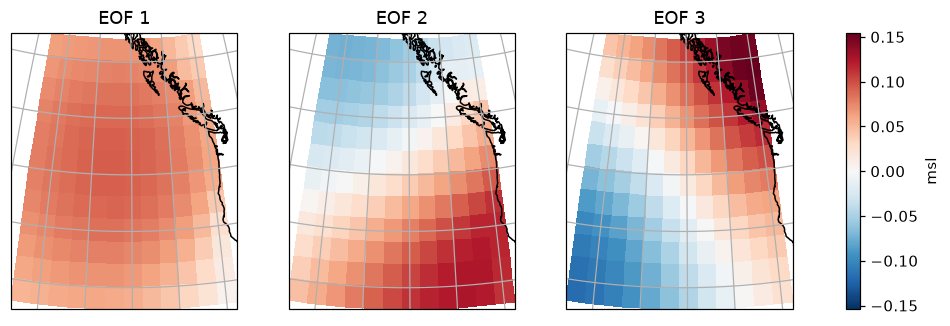

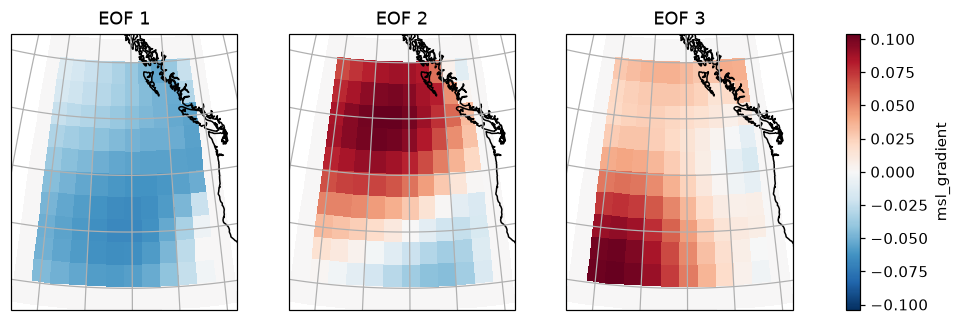

In [14]:
pca_grad.plot_eofs(vars_to_plot=["msl", "msl_gradient"], num_eofs=3, map_center=map_center)

## 8. Temporal indices with the gradient

The first three PCs of the combined **msl + spatial gradient** model, using the same full-record / 2015–2018 zoom layout as the pressure-only analysis. Percentages refer to the variance of the combined standardized feature set.


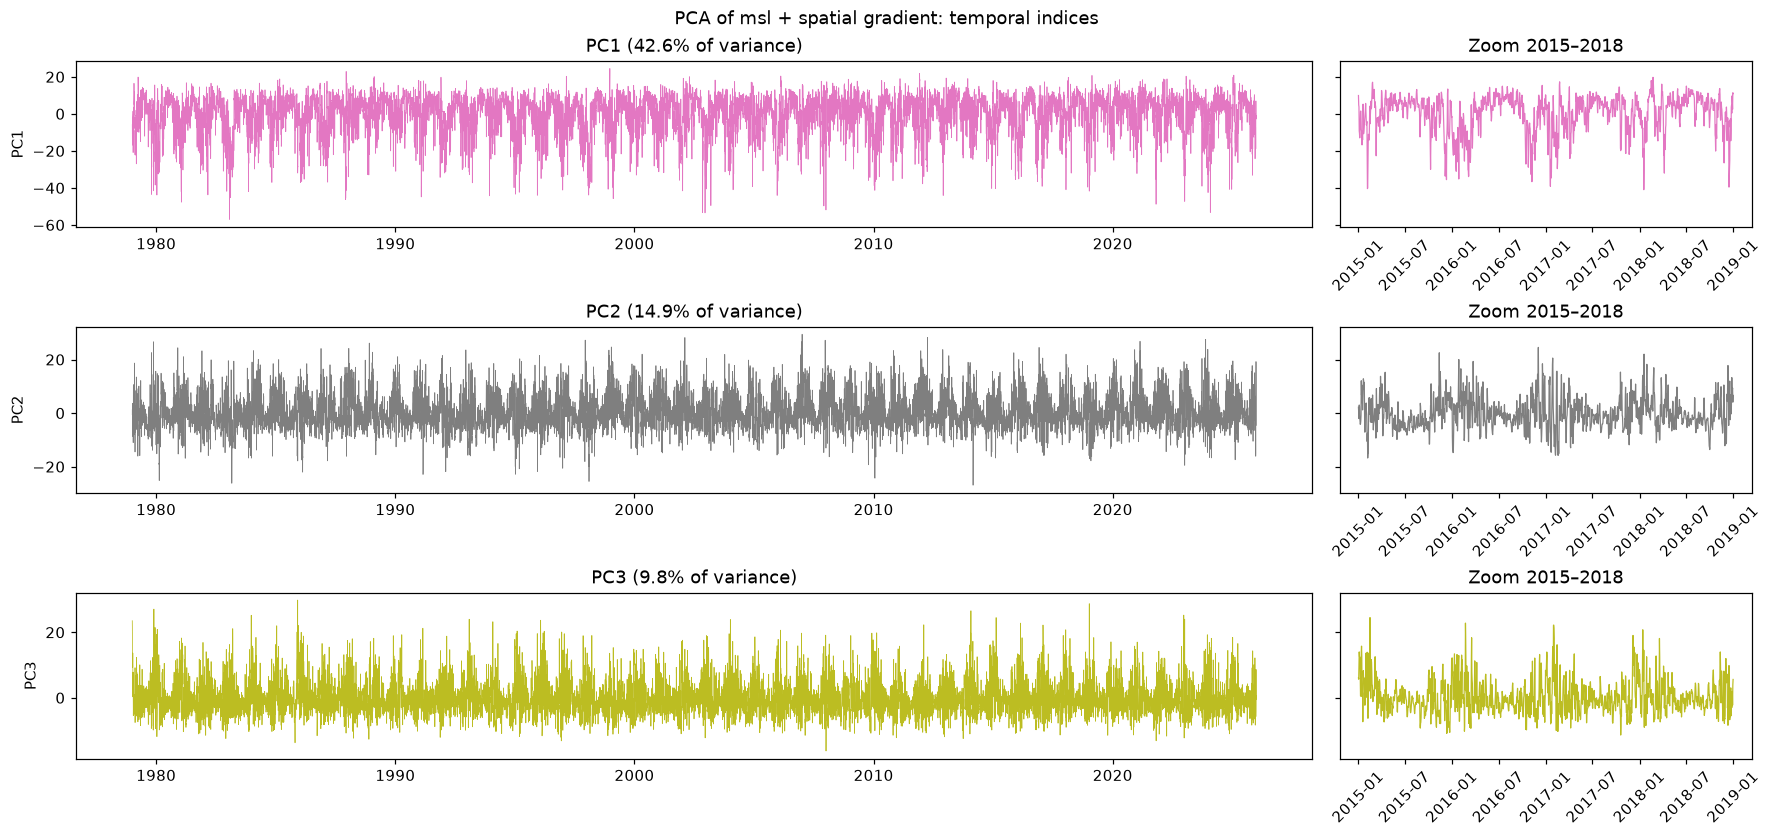

In [15]:
n_pcs_grad = min(3, pcs_grad.sizes["n_component"])
fig, axes = plt.subplots(
    n_pcs_grad, 2, figsize=(16, 2.5 * n_pcs_grad), sharey="row",
    layout="constrained", squeeze=False, gridspec_kw={"width_ratios": [3, 1]},
)
for i in range(n_pcs_grad):
    pc = pcs_grad.PCs.isel(n_component=i)
    ratio = pca_grad.explained_variance_ratio[i]
    color = f"C{i + 6}"
    axes[i, 0].plot(pc.time, pc, color=color, linewidth=0.5)
    axes[i, 0].set(ylabel=f"PC{i + 1}", title=f"PC{i + 1} ({ratio:.1%} of variance)")
    zoom = pc.sel(time=slice("2015", "2018"))
    axes[i, 1].plot(zoom.time, zoom, color=color, linewidth=0.8)
    axes[i, 1].set(title="Zoom 2015–2018")
    axes[i, 1].tick_params(axis="x", labelrotation=45)
fig.suptitle("PCA of msl + spatial gradient: temporal indices");


## 9. Save both fitted models

Save the pressure-only PCA (95% variance) and the combined pressure + gradient PCA (20 components) in `toolkit/datamining/outputs/`. BlueMath saves the fitted model, scaler, spatial coordinates and PCs, omitting the large intermediate training matrices. New inputs must use the same 2° grid, hPa pressure units and preprocessing; the combined model also requires the same gradient predictor.


In [16]:
from pathlib import Path

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "toolkit" / "datamining").is_dir()
)
output_path = repo_root / "toolkit" / "datamining" / "outputs"
output_path.mkdir(parents=True, exist_ok=True)
model_paths = {
    "msl": output_path / f"pca_msl_{region_id}_1979-2025_2deg.pkl",
    "msl_gradient": output_path / f"pca_msl_gradient_{region_id}_1979-2025_2deg.pkl",
}
for name, model in [("msl", pca), ("msl_gradient", pca_grad)]:
    model.region_bounds = {"south": south, "north": north, "west": west, "east": east}
    model.region_id = region_id
    # Write atomically so an interrupted save does not replace a valid model.
    temporary_path = model_paths[name].with_suffix(".tmp.pkl")
    model.save_model(str(temporary_path))
    temporary_path.replace(model_paths[name])
    print(f"Saved {name}: {model_paths[name]}")

# Reload later with the same BlueMath environment:
# from bluemath_tk.core.io import load_model
# pca_loaded = load_model(str(model_paths["msl"]))
# pca_grad_loaded = load_model(str(model_paths["msl_gradient"]))


Saved msl: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Repositories/BlueMath_Course_Corvallis/toolkit/datamining/outputs/pca_msl_north_pacific_31.823246N-56.885930N_147.954232W-122.997241W_1979-2025_2deg.pkl
Saved msl_gradient: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Repositories/BlueMath_Course_Corvallis/toolkit/datamining/outputs/pca_msl_gradient_north_pacific_31.823246N-56.885930N_147.954232W-122.997241W_1979-2025_2deg.pkl


## Summary

- Crop the requested North Pacific rectangle before spatial averaging or loading yearly fields.
- Average 0.25° daily pressure to 2° over 1979–2025: **144 regional grid cells**.
- Fit a pressure-only PCA retaining 95% variance and a second PCA with pressure plus its spatial-gradient predictor.
- Interpret newly fitted regional EOFs and their daily PCs.
- Save both regional models with explicit domain metadata and filenames for the wave regressions.
